# Instacart Reorder Behaviour Analysis

**Business scenario:** Acting as a data analyst at Instacart, I was 
asked to understand what drives customers to reorder products. 

**Dataset:** 3.4M orders, 32M order-product rows, 21 departments.

**Tools:** Python, pandas, Kaggle Notebooks.

**Key finding:** Reorder behaviour is driven by habit. Dairy and 
produce departments retain at 67%, personal care at 32%. 
Frequent shoppers reorder at 3x the rate of occasional ones. 
Sunday 7am is the peak reorder window.

**Questions answered:**
- Q1: What is the overall reorder rate? → 58.97%
- Q2: Which departments have highest loyalty? → Dairy 67%, Personal care 32%
- Q3: When do customers reorder most? → Sunday, 6–8am
- Q4: Does frequency predict loyalty? → Yes, 3x difference low vs high

In [1]:

import pandas as pd

orders = pd.read_csv('/kaggle/input/datasets/psparks/instacart-market-basket-analysis/orders.csv')
products = pd.read_csv('/kaggle/input/datasets/psparks/instacart-market-basket-analysis/products.csv')
aisles = pd.read_csv('/kaggle/input/datasets/psparks/instacart-market-basket-analysis/aisles.csv')
departments = pd.read_csv('/kaggle/input/datasets/psparks/instacart-market-basket-analysis/departments.csv')
order_products = pd.read_csv('/kaggle/input/datasets/psparks/instacart-market-basket-analysis/order_products__prior.csv')

print("=== ORDERS ===")
print(orders.columns.tolist())
print(orders.shape)

print("\n=== PRODUCTS ===")
print(products.columns.tolist())

print("\n=== ORDER PRODUCTS ===")
print(order_products.columns.tolist())
print(order_products.shape)




=== ORDERS ===
['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
(3421083, 7)

=== PRODUCTS ===
['product_id', 'product_name', 'aisle_id', 'department_id']

=== ORDER PRODUCTS ===
['order_id', 'product_id', 'add_to_cart_order', 'reordered']
(32434489, 4)



**Business scenario:** I'm acting as a data analyst at Instacart. 
My manager wants to understand what drives reorder behaviour 
which departments, times of day, and order patterns lead customers 
to buy the same products again.

**Q1: What is the baseline reorder rate across all orders?**

In [2]:
# ============================================================
# Q1: WHAT IS THE OVERALL REORDER RATE?
# Business question: Out of all products ever ordered on
# Instacart, what percentage are repeat purchases?
# This will be my baseline metric, everything else will be
# compared against this number.
# ============================================================

# 'reordered' column is 1 if the customer bought this product
# before and it is 0 if it's their first time buying it.
# .mean() on a 0/1 column gives me the proportion directly.

reorder_rate = order_products['reordered'].mean() * 100

# Total rows = the total product-order combinations made
total_products_ordered = len(order_products)

# Sum of 1s = the count of reordered items
total_reordered = order_products['reordered'].sum()

print(f"Overall reorder rate: {reorder_rate:.2f}%")
print(f"Total product-order lines analyzed: {total_products_ordered:,}")
print(f"Of which these many were reorders: {total_reordered:,}")
print()
print("Interpretation: Roughly 6 in every 10 products")
print("is what a customer adds to cart that they've bought before.")

Overall reorder rate: 58.97%
Total product-order lines analyzed: 32,434,489
Of which these many were reorders: 19,126,536

Interpretation: Roughly 6 in every 10 products
is what a customer adds to cart that they've bought before.


## Q2: Which departments have the highest and lowest reorder rates?

The overall reorder rate is 58.97%. Now I will break it down by department 
to find which categories drive more loyalty and which ones are one-time purchases.
This will tell a product team where to focus retention efforts.

In [3]:
# ============================================================
# Q2: REORDER RATE BY DEPARTMENT
# Business question: Which departments have above/below average
# reorder rates? This will explain where customer loyalty is strong
# and where it breaks down.
# ============================================================

# Step 1: Link order_products to products to get department_id
# I need to join because reordered column is in order_products
# but department info is in products table
order_with_products = order_products.merge(products, on='product_id', how='left')

# Step 2: Link department_id to department name
# I only have department_id numbers so I will need readable names
order_with_dept = order_with_products.merge(departments, on='department_id', how='left')

# Step 3: Group by department and calculate reorder rate for each
# .agg lets us calculate multiple things at once per group
dept_reorder = order_with_dept.groupby('department').agg(
    total_orders=('reordered', 'count'),       # total times any product from this dept was ordered
    total_reorders=('reordered', 'sum'),        # how many of those were reorders
    reorder_rate=('reordered', 'mean')          # proportion reordered = loyalty score
).reset_index()

# Step 4: Convert to percentage and sorting highest to lowest
dept_reorder['reorder_rate_pct'] = (dept_reorder['reorder_rate'] * 100).round(2)
dept_reorder = dept_reorder.sort_values('reorder_rate_pct', ascending=False)

# Step 5: Print results
print("Reorder rate by department (sorted highest to lowest):")
print("=" * 55)
print(f"{'Department':<25} {'Reorder Rate':>12} {'Total Orders':>15}")
print("=" * 55)
for _, row in dept_reorder.iterrows():
    print(f"{row['department']:<25} {row['reorder_rate_pct']:>11}% {row['total_orders']:>15,}")

print()
print(f"Baseline overall reorder rate: 58.97%")
print()
print("Top 3 most loyal departments (above baseline):")
print(dept_reorder.head(3)[['department', 'reorder_rate_pct']].to_string(index=False))
print()
print("Bottom 3 least loyal departments (below baseline):")
print(dept_reorder.tail(3)[['department', 'reorder_rate_pct']].to_string(index=False))

Reorder rate by department (sorted highest to lowest):
Department                Reorder Rate    Total Orders
dairy eggs                       67.0%       5,414,016
beverages                       65.35%       2,690,129
produce                         64.99%       9,479,291
bakery                          62.81%       1,176,787
deli                            60.77%       1,051,249
pets                            60.13%          97,724
babies                           57.9%         423,802
bulk                             57.7%          34,573
snacks                          57.42%       2,887,550
alcohol                         56.99%         153,696
meat seafood                    56.77%         708,931
breakfast                       56.09%         709,569
frozen                          54.19%       2,236,432
dry goods pasta                 46.11%         866,627
canned goods                    45.74%       1,068,058
other                            40.8%          36,291
household 

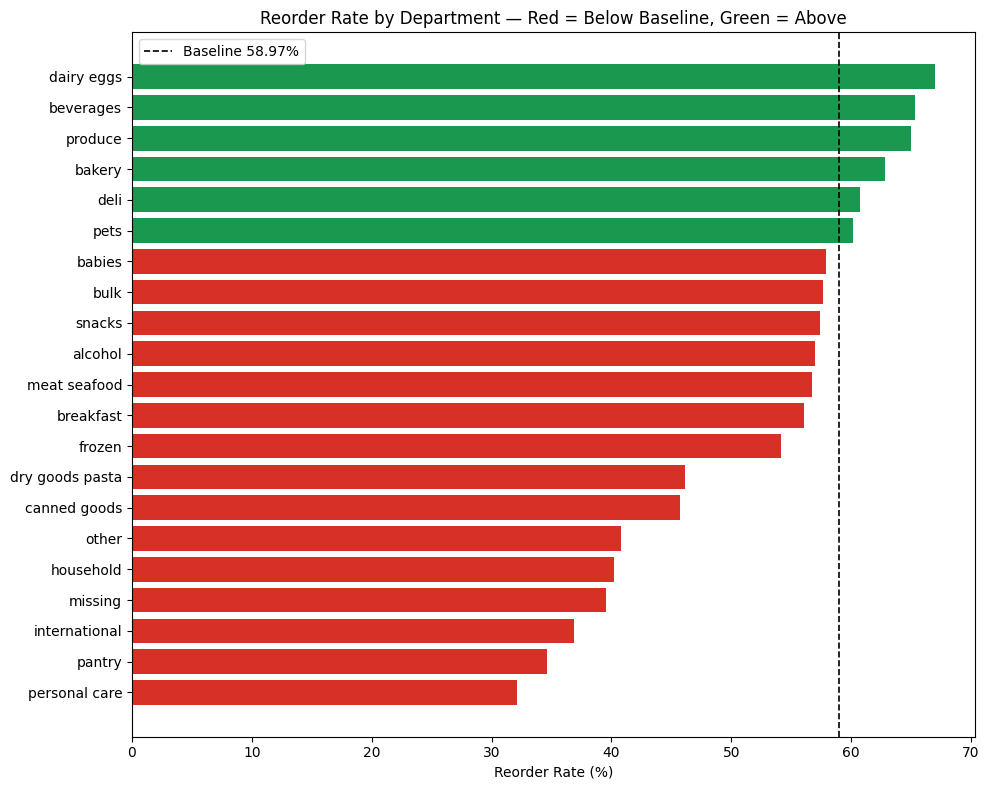

In [4]:
import matplotlib.pyplot as plt

# Sort for cleaner visual
dept_plot = dept_reorder.sort_values('reorder_rate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d73027' if x < 58.97 else '#1a9850' for x in dept_plot['reorder_rate_pct']]
ax.barh(dept_plot['department'], dept_plot['reorder_rate_pct'], color=colors)
ax.axvline(x=58.97, color='black', linestyle='--', linewidth=1.2, label='Baseline 58.97%')
ax.set_xlabel('Reorder Rate (%)')
ax.set_title('Reorder Rate by Department — Red = Below Baseline, Green = Above')
ax.legend()
plt.tight_layout()
plt.savefig('q2_department_reorder.png', dpi=150, bbox_inches='tight')
plt.show()


##  Finding: Departments split into habit buyers vs discovery buyers

The data shows two clearly different types of shopping behaviour. 

Dairy, beverages, and produce are at 65–67% of reordering rate, which is above 
the 58.97% average. These are weekly habit purchases: milk, juice, 
bananas. Customers do not think before reordering them.

Personal care, pantry, and international sit at 32–37% reorder rate, 
which is nearly half the baseline. These are one-time or exploratory purchases. 
Example: A customer tries a new shampoo or an international sauce once and 
rarely comes back for the exact same product.

The 35-point gap between the most and least loyal departments is the 
key finding. It means Instacart should not treat all departments the 
same way in its recommendation engine.

Instead, for habit departments the focus should be on stock reliability 
and subscription reminders. 
Customers already want to reorder, we just have to make it frictionless.

And for discovery departments the focus should be on "similar products you might like" 
nudges. The goal is to convert a one-time buyer into someone who finds 
a new favourite product in that category.


## Q3: Does time of day or day of week affect reorder rate?

I know WHAT people reorder. Now I will ask WHEN. If reorder rate 
spikes at certain hours or days, that tells the marketing team 
exactly when to send reminder notifications.

In [5]:
# ============================================================
# Q3: REORDER RATE BY HOUR OF DAY AND DAY OF WEEK
# Business question: When do customers make reorder decisions?
# If reorder rate is higher at specific times, that's when
# push notifications and email reminders should be sent.
# ============================================================

# Step 1: Bring in the hour and day columns from orders table
# order_products has reordered flag but no time info
# orders table has time info but no reordered flag
# We need both — so we join them on order_id
order_with_time = order_products.merge(
    orders[['order_id', 'order_hour_of_day', 'order_dow']],
    on='order_id',
    how='left'
)

# Step 2: Reorder rate by hour of day (0 = midnight, 23 = 11pm)
hourly_reorder = order_with_time.groupby('order_hour_of_day').agg(
    reorder_rate=('reordered', 'mean')
).reset_index()
hourly_reorder['reorder_rate_pct'] = (hourly_reorder['reorder_rate'] * 100).round(2)

# Step 3: Reorder rate by day of week (0 = Saturday, 1 = Sunday in Instacart data)
daily_reorder = order_with_time.groupby('order_dow').agg(
    reorder_rate=('reordered', 'mean')
).reset_index()
daily_reorder['reorder_rate_pct'] = (daily_reorder['reorder_rate'] * 100).round(2)

# Map day numbers to names for readability
day_names = {0: 'Saturday', 1: 'Sunday', 2: 'Monday',
             3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday'}
daily_reorder['day_name'] = daily_reorder['order_dow'].map(day_names)

# Step 4: Print hourly results
print("Reorder rate by hour of day:")
print("=" * 40)
for _, row in hourly_reorder.iterrows():
    bar = '█' * int(row['reorder_rate_pct'] / 3)
    print(f"Hour {int(row['order_hour_of_day']):02d}:00  {row['reorder_rate_pct']:>5}%  {bar}")

print()
print("Reorder rate by day of week:")
print("=" * 40)
for _, row in daily_reorder.iterrows():
    bar = '█' * int(row['reorder_rate_pct'] / 3)
    print(f"{row['day_name']:<12} {row['reorder_rate_pct']:>5}%  {bar}")

print()
# Find peak and low hours
peak_hour = hourly_reorder.loc[hourly_reorder['reorder_rate_pct'].idxmax()]
low_hour = hourly_reorder.loc[hourly_reorder['reorder_rate_pct'].idxmin()]
print(f"Peak reorder hour: {int(peak_hour['order_hour_of_day'])}:00 at {peak_hour['reorder_rate_pct']}%")
print(f"Lowest reorder hour: {int(low_hour['order_hour_of_day'])}:00 at {low_hour['reorder_rate_pct']}%")

Reorder rate by hour of day:
Hour 00:00  56.55%  ██████████████████
Hour 01:00  55.71%  ██████████████████
Hour 02:00  55.45%  ██████████████████
Hour 03:00  55.95%  ██████████████████
Hour 04:00  57.12%  ███████████████████
Hour 05:00  60.79%  ████████████████████
Hour 06:00  63.65%  █████████████████████
Hour 07:00  64.45%  █████████████████████
Hour 08:00  63.19%  █████████████████████
Hour 09:00  61.94%  ████████████████████
Hour 10:00  60.03%  ████████████████████
Hour 11:00  58.73%  ███████████████████
Hour 12:00  57.93%  ███████████████████
Hour 13:00  57.99%  ███████████████████
Hour 14:00  58.13%  ███████████████████
Hour 15:00  58.07%  ███████████████████
Hour 16:00  57.86%  ███████████████████
Hour 17:00  57.48%  ███████████████████
Hour 18:00  57.34%  ███████████████████
Hour 19:00  57.42%  ███████████████████
Hour 20:00  58.23%  ███████████████████
Hour 21:00  59.07%  ███████████████████
Hour 22:00  58.53%  ███████████████████
Hour 23:00  57.97%  ███████████████████

Reord

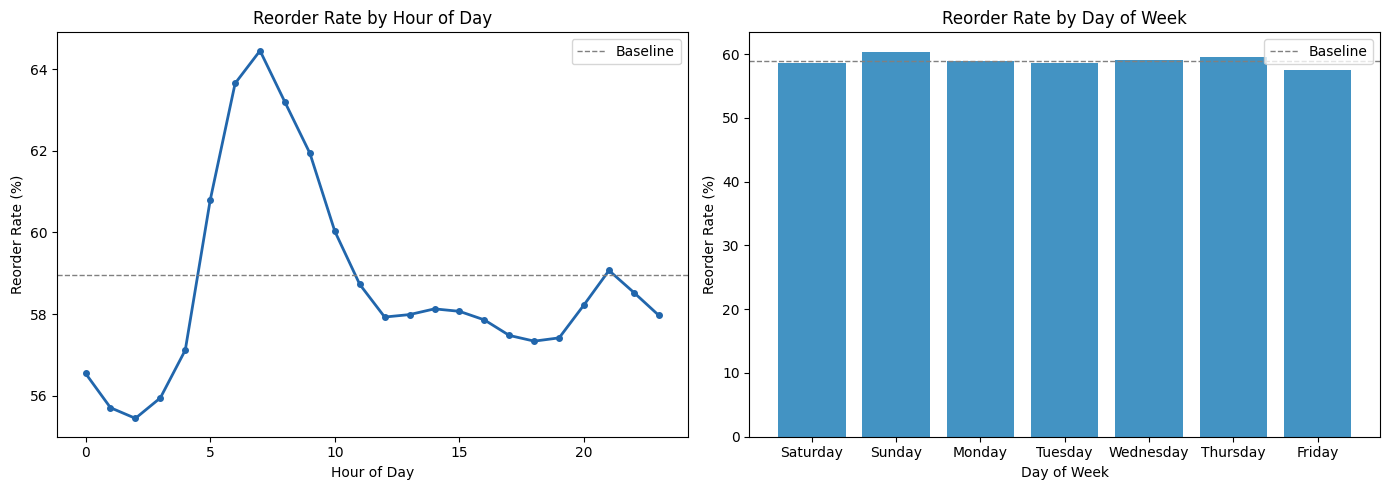

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Hourly chart
ax1.plot(hourly_reorder['order_hour_of_day'], 
         hourly_reorder['reorder_rate_pct'], 
         color='#2166ac', linewidth=2, marker='o', markersize=4)
ax1.axhline(y=58.97, color='gray', linestyle='--', linewidth=1, label='Baseline')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Reorder Rate (%)')
ax1.set_title('Reorder Rate by Hour of Day')
ax1.legend()

# Daily chart
ax2.bar(daily_reorder['day_name'], 
        daily_reorder['reorder_rate_pct'], 
        color='#4393c3')
ax2.axhline(y=58.97, color='gray', linestyle='--', linewidth=1, label='Baseline')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Reorder Rate (%)')
ax2.set_title('Reorder Rate by Day of Week')
ax2.legend()

plt.tight_layout()
plt.savefig('q3_time_reorder.png', dpi=150, bbox_inches='tight')
plt.show()

##  Finding: Early morning is when customers make reorder decisions

Looking at hour of day, reorder rate peaks between 6am and 8am 
(63–64%), then drops through the afternoon and late night. 
The lowest point is 2am at 55.45% which is a 9-point swing across the day.

This makes sense though. People plan their grocery reorders in 
the morning while making coffee or writing their daily to-do list. 
Late night browsing tends to be exploratory which is trying new products 
rather than restocking familiar ones.

For day of week, Sunday has the highest reorder rate at 60.38% 
and Friday the lowest at 57.44%. This can be understood because most of us
plan the week ahead, usually on Sundays,i.e. restocking staples before Monday.

Business implication: push notifications and reorder reminder 
emails should be sent Sunday morning between 6am and 8am. 
That is when customers are most mentally prepared to restock 
and least likely to browse something new instead.

## Q4: Do frequent shoppers reorder more?

We know WHAT people reorder and WHEN. Now we ask WHO. 

If customers who order more frequently also reorder more, 
that tells us loyalty and frequency are linked and retaining 
high-frequency customers is worth disproportionate investment.

In [7]:
# ============================================================
# Q4: DOES ORDER FREQUENCY AFFECT REORDER RATE?
# Business question: Do customers who shop more often also
# reorder more? If yes, frequency = loyalty, and keeping
# high-frequency customers is the highest ROI retention play.
# ============================================================

# Step 1: Count how many orders each user has placed
# This tells us each customer's frequency level
user_order_count = orders.groupby('user_id')['order_id'].count().reset_index()
user_order_count.columns = ['user_id', 'total_orders']

# Step 2: Bucket users into frequency segments
# We use pd.cut to split into 4 equal-width groups
# Labels describe the customer type plainly
user_order_count['frequency_segment'] = pd.cut(
    user_order_count['total_orders'],
    bins=[0, 5, 15, 30, 100],
    labels=['low (1-5 orders)', 'medium (6-15)', 'high (16-30)', 'very high (31+)']
)

# Step 3: Link each order back to its user's frequency segment
orders_with_segment = orders.merge(user_order_count[['user_id', 'frequency_segment']],
                                    on='user_id', how='left')

# Step 4: Link order_products to get reordered flag per segment
full_data = order_products.merge(orders_with_segment[['order_id', 'frequency_segment']],
                                  on='order_id', how='left')

# Step 5: Calculate reorder rate per frequency segment
segment_reorder = full_data.groupby('frequency_segment', observed=True).agg(
    total_orders=('reordered', 'count'),
    reorder_rate=('reordered', 'mean')
).reset_index()
segment_reorder['reorder_rate_pct'] = (segment_reorder['reorder_rate'] * 100).round(2)

# Step 6: Print results
print("Reorder rate by customer frequency segment:")
print("=" * 55)
print(f"{'Segment':<25} {'Reorder Rate':>12} {'Total Orders':>15}")
print("=" * 55)
for _, row in segment_reorder.iterrows():
    print(f"{str(row['frequency_segment']):<25} {row['reorder_rate_pct']:>11}% {row['total_orders']:>15,}")

print()
print(f"Baseline overall reorder rate: 58.97%")
print()

# Step 7: Calculate the lift — how much more do loyal customers reorder?
low = segment_reorder[segment_reorder['frequency_segment']=='low (1-5 orders)']['reorder_rate_pct'].values[0]
high = segment_reorder[segment_reorder['frequency_segment']=='very high (31+)']['reorder_rate_pct'].values[0]
print(f"Reorder rate lift from low to very high frequency: {(high - low).round(2)} percentage points")
print(f"Very high frequency customers reorder at {(high/low*100).round(1)}% the rate of low frequency customers")

Reorder rate by customer frequency segment:
Segment                   Reorder Rate    Total Orders
low (1-5 orders)                23.46%       1,441,523
medium (6-15)                   42.21%       7,794,701
high (16-30)                    58.26%       8,523,249
very high (31+)                 71.77%      14,675,016

Baseline overall reorder rate: 58.97%

Reorder rate lift from low to very high frequency: 48.31 percentage points
Very high frequency customers reorder at 305.9% the rate of low frequency customers


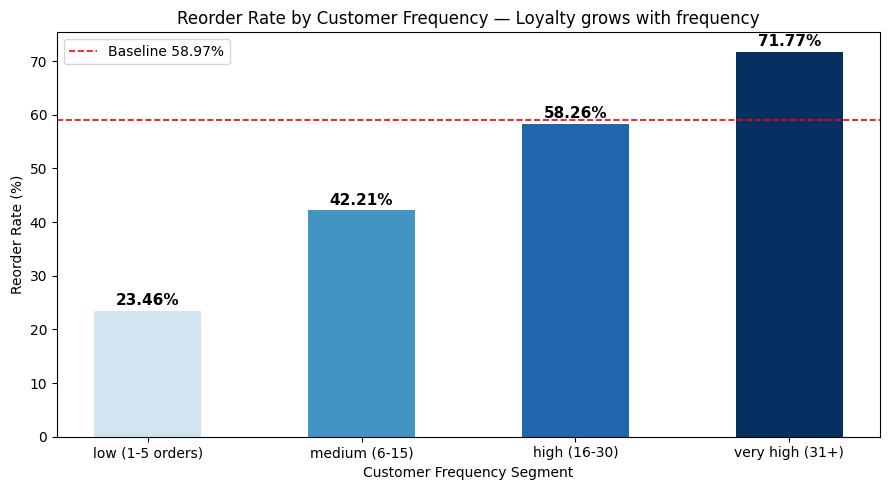

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

segments = segment_reorder['frequency_segment'].astype(str)
rates = segment_reorder['reorder_rate_pct']
colors = ['#d1e5f0', '#4393c3', '#2166ac', '#053061']

bars = ax.bar(segments, rates, color=colors, width=0.5)
ax.axhline(y=58.97, color='red', linestyle='--', linewidth=1.2, label='Baseline 58.97%')

# Add value labels on top of each bar
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Customer Frequency Segment')
ax.set_ylabel('Reorder Rate (%)')
ax.set_title('Reorder Rate by Customer Frequency — Loyalty grows with frequency')
ax.legend()
plt.tight_layout()
plt.savefig('q4_frequency_reorder.png', dpi=150, bbox_inches='tight')
plt.show()

## Finding: Frequency and loyalty are the same thing

Customer segments show a clean, linear relationship between 
how often someone shops and how likely they are to reorder.

Low frequency customers (1–5 orders) reorder only 23% of the time.
Very high frequency customers (31+ orders) reorder 71% of the time.

That is a 48 percentage point gap and frequent customers place 
14.6 million of the 32 million total orders in this dataset. 
They are not just more loyal, they are the majority of the business.

This means retention is more valuable than acquisition here. 
Keeping one very high frequency customer is worth roughly 3 times 
more than acquiring a new occasional shopper, purely based on 
reorder behaviour alone.

## Final Recommendation

Across all four questions, one theme emerges consistently: 
Instacart's reorder behaviour is driven by habit, not discovery.

Three specific actions follow from this analysis:

1. Protect dairy, beverages, and produce above all else. 
   These departments drive 65–67% reorder rates. Any stock 
   reliability issue here directly breaks customer habits and 
   risks losing your highest-value customers.

2. Send reorder reminders on Sunday mornings between 6am and 8am. 
   Reorder rate peaks at 64.45% at 7am and is highest on Sundays. 
   This is the single highest-conversion window for a re-engagement 
   notification.

3. Build a loyalty programme specifically for high-frequency customers. 
   The jump from medium (42%) to very high frequency (71%) reorder rate 
   shows that once a customer crosses a certain order threshold, 
   their behaviour shifts fundamentally. An intervention at the 
   medium stage like a small reward or a subscription nudge  could 
   accelerate that transition and significantly increase lifetime value.